# Eye Blink Detection Experimental Results

## Configuration

In [1]:
!chmod +x configure.sh
!./configure.sh

--2022-08-13 10:35:06--  https://zenodo.org/record/2529036/files/s000_noglasses.tar?download=1
Resolving zenodo.org (zenodo.org)... 137.138.76.77
Connecting to zenodo.org (zenodo.org)|137.138.76.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 798545920 (762M) [application/octet-stream]
Saving to: ‘dataset/rt_bene/archive/s000_ng.tar’

dataset/rt_bene/arc 100%[===================>] 761.55M  41.8MB/s    in 25s     

2022-08-13 10:35:32 (30.3 MB/s) - ‘dataset/rt_bene/archive/s000_ng.tar’ saved [798545920/798545920]

--2022-08-13 10:35:35--  https://zenodo.org/record/3685316/files/s000_blink_labels.csv?download=1
Resolving zenodo.org (zenodo.org)... 137.138.76.77
Connecting to zenodo.org (zenodo.org)|137.138.76.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 335650 (328K) [text/plain]
Saving to: ‘dataset/rt_bene/raw/s000_noglasses/blink_labels.csv’

dataset/rt_bene/raw 100%[===================>] 327.78K  1.93MB/s    in 0.2s    

202

## Dependencies

In [2]:
!pip install mediapipe

import mediapipe as mp
import cv2
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import sklearn.metrics as metrics

import statsmodels.formula.api as smf

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 32.9 MB 1.2 MB/s 


/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


## Constant and Helpers

In [3]:
landmark_indices = [
    # left_iris
    469, 470,
    471, 472,
    
    # right iris
    474, 475,
    476, 477,

    # nose
    1,

    # left eye, right to left
    158, 159, 160,
    153, 145, 144,
    # left eye left - right
    33, 133, 

    # right eye, right to left
    387, 386, 385,
    373, 374, 380,
    
    # right eye left - right
    362, 263
]
coor_columns = [item for sublist in [(f'{idx}_x', f'{idx}_y') for idx in landmark_indices] for item in sublist]

In [4]:
def read_blink_df(id: int) -> pd.DataFrame:
  blink_df = pd.read_csv(f'dataset/rt_bene/raw/s{id:03}_noglasses/blink_labels.csv', names=['image', 'is_blinking'])
  blink_df.image = blink_df.image.str.replace('left', f'dataset/rt_bene/raw/s{id:03}_noglasses/natural/face/face')
  return blink_df

In [5]:
def infer_static_images(images, callback):
  N_IMAGES = len(images)
  na_idx = []
  mp_face_mesh = mp.solutions.face_mesh
  with mp_face_mesh.FaceMesh(
      static_image_mode=True,
      max_num_faces=1,
      refine_landmarks=True,
      min_detection_confidence=0.5) as face_mesh:
    for idx, file in enumerate(images):
      print(f'{idx / N_IMAGES * 100}% analyzed', end = '\r')
      image = cv2.imread(file)
      # Convert the BGR image to RGB before processing.
      try:
        res = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
      except:
        na_idx.append(idx)
        print(f'Exception occured while processing {file} at index {idx}')
        continue
      
      # Print and draw face mesh landmarks on the image.
      if not res.multi_face_landmarks:
        na_idx.append(idx)
        continue
      callback(idx, image, res.multi_face_landmarks)     
  return na_idx

def record_coor_df_decorator(coor_df):
  def wrapper(idx, image, multi_face_landmarks):
    for face_landmarks in multi_face_landmarks:
        ls = face_landmarks
        xs = [landmark.x for landmark in face_landmarks.landmark]
        ys = [landmark.y for landmark in face_landmarks.landmark]
        zs = [landmark.z for landmark in face_landmarks.landmark]
        xs = np.array(xs)
        ys = np.array(ys)
        zs = np.array(zs)
        std_xs = (xs - xs.mean()) / xs.std()
        std_ys = (ys - ys.mean()) / ys.std()
        std_zs = (zs - zs.mean()) / zs.std()

        for lm_idx in landmark_indices:
          coor_df.loc[idx, f'{lm_idx}_x'] = std_xs[lm_idx]
          coor_df.loc[idx, f'{lm_idx}_y'] = std_ys[lm_idx]
  return wrapper

def record_candid_coor_df_decorator(coor_df):
  def wrapper(idx, image, multi_face_landmarks):
    width = image.shape[0]
    height = image.shape[1]
    for face_landmarks in multi_face_landmarks:
        ls = face_landmarks
        xs = [landmark.x for landmark in face_landmarks.landmark]
        ys = [landmark.y for landmark in face_landmarks.landmark]
        zs = [landmark.z for landmark in face_landmarks.landmark]
        xs = np.array(xs)
        ys = np.array(ys)
        zs = np.array(zs)
        candid_xs = xs * width
        candid_ys = ys * height
        candid_zs = zs

        for lm_idx in landmark_indices:
          coor_df.loc[idx, f'{lm_idx}_x'] = candid_xs[lm_idx]
          coor_df.loc[idx, f'{lm_idx}_y'] = candid_ys[lm_idx]
  return wrapper

def annotate_static_images(images, callback):
  mp_drawing = mp.solutions.drawing_utils
  mp_drawing_styles = mp.solutions.drawing_styles
  mp_face_mesh = mp.solutions.face_mesh

  # For static images:
  IMAGE_FILES = images
  blinks = []
  with mp_face_mesh.FaceMesh(
      static_image_mode=True,
      max_num_faces=1,
      refine_landmarks=True,
      min_detection_confidence=0.5) as face_mesh:
    for idx, file in enumerate(IMAGE_FILES):
      image = cv2.imread(file)
      # Convert the BGR image to RGB before processing.
      results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

      # Print and draw face mesh landmarks on the image.
      if not results.multi_face_landmarks:
        continue
      annotated_image = image.copy()
      for face_landmarks in results.multi_face_landmarks:
        mp_drawing.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles
            .get_default_face_mesh_tesselation_style())
        mp_drawing.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_CONTOURS,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles
            .get_default_face_mesh_contours_style())
        mp_drawing.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_IRISES,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles
            .get_default_face_mesh_iris_connections_style())
      callback(idx, annotated_image)

## Prepare Training Data

In [6]:
train_blink_df = pd.concat(
    [read_blink_df(id) for id in range(14)]
)

train_coor_df = pd.DataFrame(
    data = {
        col: np.zeros(train_blink_df.shape[0])
        for col in coor_columns
    }, 
)

na_idx = infer_static_images(train_blink_df.image.to_list(), record_coor_df_decorator(train_coor_df))
train_blink_df[train_coor_df.columns] = train_coor_df
train_blink_df = train_blink_df.drop(train_blink_df.index[na_idx])
train_blink_df.to_csv('train_rtbene_coors.csv')

Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000234_rgb.png at index 98185
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000235_rgb.png at index 98186
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000236_rgb.png at index 98187
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000237_rgb.png at index 98188
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000303_rgb.png at index 98189
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000304_rgb.png at index 98190
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000305_rgb.png at index 98191
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000306_rgb.png at index 98192
Exception occured while processing dataset/rt_bene/raw/s

In [7]:
train_blink_df = pd.concat(
    [read_blink_df(id) for id in range(14)]
)

train_coor_df = pd.DataFrame(
    data = {
        col: np.zeros(train_blink_df.shape[0])
        for col in coor_columns
    }, 
)

na_idx = infer_static_images(train_blink_df.image.to_list(), record_candid_coor_df_decorator(train_coor_df))
train_blink_df[train_coor_df.columns] = train_coor_df
train_blink_df = train_blink_df.drop(train_blink_df.index[na_idx])
train_blink_df.to_csv('train_rtbene_candid_coors.csv')

Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000234_rgb.png at index 98185
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000235_rgb.png at index 98186
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000236_rgb.png at index 98187
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000237_rgb.png at index 98188
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000303_rgb.png at index 98189
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000304_rgb.png at index 98190
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000305_rgb.png at index 98191
Exception occured while processing dataset/rt_bene/raw/s012_noglasses/natural/face/face_000306_rgb.png at index 98192
Exception occured while processing dataset/rt_bene/raw/s

## Prepare Evaluation Data

In [8]:
eval_blink_df = pd.concat(
    [read_blink_df(id) for id in range(14, 17)]
)
eval_coor_df = pd.DataFrame(
    data = {
        col: np.zeros(eval_blink_df.shape[0])
        for col in coor_columns
    }, 
)
na_idx = infer_static_images(eval_blink_df.image.to_list(), record_coor_df_decorator(eval_coor_df))
eval_blink_df[eval_coor_df.columns] = eval_coor_df
eval_blink_df = eval_blink_df.drop(eval_blink_df.index[na_idx])
eval_blink_df.to_csv('test_rtbene_coors.csv')

In [9]:
eval_blink_df = pd.concat(
    [read_blink_df(id) for id in range(14, 17)]
)
eval_coor_df = pd.DataFrame(
    data = {
        col: np.zeros(eval_blink_df.shape[0])
        for col in coor_columns
    }, 
)
na_idx = infer_static_images(eval_blink_df.image.to_list(), record_candid_coor_df_decorator(eval_coor_df))
eval_blink_df[eval_coor_df.columns] = eval_coor_df
eval_blink_df = eval_blink_df.drop(eval_blink_df.index[na_idx])
eval_blink_df.to_csv('test_rtbene_candid_coors.csv')

## AD Hoc blink regression

In [ ]:
# threshold = std_xs[1] * 0.0308 + std_ys[1] * 0.0803 + 0.1476

## Read Training data and Evaluation Data

In [51]:
train_df = pd.read_csv('train_rtbene_coors.csv', index_col = 0)
train_blinking_df = train_df[train_df.is_blinking == 1.0]
eval_df = pd.read_csv('test_rtbene_coors.csv', index_col = 0)

## Eye Lid Distance Models

### Helpers

In [11]:
def get_point(df, point):
  return df[[f'{point}_x', f'{point}_y']]

def get_distance(df, p1, p2):
  return np.sqrt(np.square(get_point(df, p1).to_numpy() - get_point(df, p2).to_numpy()).sum(axis = 1))

def draw_stats_result(df, data, results, control_var):
  crit = 1 - (95 / 100)
  df = df.shape[0] - 2
  margin_error = scipy.stats.t.ppf(crit, df) * results.bse[0]

  fig, axes = plt.subplots(ncols = 2, figsize = (20, 10))
  axes = axes.flatten()
  predicted_data = data
  predicted_data['predicted'] = results.predict(data)

  print(results.params[0] + margin_error)
  predicted_data['upper_predicted'] = (results.params[0] + margin_error) * data['nose_y']

  sns.scatterplot(data = predicted_data, x = 'nose_x', y = control_var, ax = axes[0])
  sns.scatterplot(data = predicted_data, x = 'nose_x', y = 'predicted', ax = axes[0])
  # sns.scatterplot(data = predicted_data, x = 'nose_x', y = 'upper_predicted', ax = axes[0])
  sns.scatterplot(data = data, x = 'nose_y', y = control_var, ax = axes[1])
  sns.scatterplot(data = predicted_data, x = 'nose_y', y = 'predicted', ax = axes[1])

In [21]:
def evaluate_dist_ols_results(results):
  eval_blinking_df = eval_df[eval_df.is_blinking == 1.0]
  eval_eyelid_dist = np.sqrt(np.square(get_point(eval_blinking_df, 159).to_numpy() - get_point(eval_blinking_df, 145).to_numpy()).sum(axis = 1))
  eval_nose_coor = get_point(eval_blinking_df, 1)
  data = pd.DataFrame(
      data = {
          'eyelid_dist': eval_eyelid_dist,
          'nose_x': eval_nose_coor[eval_nose_coor.columns[0]],
          'nose_y': eval_nose_coor[eval_nose_coor.columns[1]],
      }
  )
  y_cap = results.predict(data)
  mae = metrics.mean_squared_error(data['eyelid_dist'], y_cap)
  print(f'Mean Squared Error of Threshold Regression: {mae}')
  eval_eyelid_dist = np.sqrt(np.square(get_point(eval_df, 159).to_numpy() - get_point(eval_df, 145).to_numpy()).sum(axis = 1))
  eval_nose_coor = get_point(eval_df, 1)
  eval_data = pd.DataFrame(
      data = {
          'eyelid_dist': eval_eyelid_dist,
          'nose_x': eval_nose_coor[eval_nose_coor.columns[0]],
          'nose_y': eval_nose_coor[eval_nose_coor.columns[1]],
      }
  )
  eval_data['threshold'] = results.predict(eval_data)
  eval_data['is_blinking'] = (eval_data.eyelid_dist < (eval_data.threshold)).astype(float) 
  valid_idx = eval_df['is_blinking'] != 0.5
  return eval_df[valid_idx].is_blinking, eval_data[valid_idx].is_blinking

def draw_dist_ols_confusion(results):
  labels = [0.0, 1.0]
  labels_2 = ['no blink', 'blink']
  y, y_cap = evaluate_dist_ols_results(results)

  print(f'F1 Score: {metrics.f1_score(y, y_cap)}')
  print(f'Accuracy: {metrics.accuracy_score(y, y_cap)}')
  print(f'ROC AUC Score: {metrics.roc_auc_score(y, y_cap)}')

  cf_matrix = metrics.confusion_matrix(y, y_cap, labels = labels)
  ax = sns.heatmap(cf_matrix, annot=True, 
              fmt='2', cmap='Blues')

  ax.set_title('Confusion Matrix for predicted CMU face dataset alignments\n\n');
  ax.set_xlabel('\nPredicted Alignment')
  ax.set_ylabel('Actual Alignment');

  ## Ticket labels - List must be in alphabetical order
  ax.xaxis.set_ticklabels(labels_2)
  ax.yaxis.set_ticklabels(labels_2)

### Orientation and Eye Lid Closeness on Training Data

In [27]:
train_eyelid_dist = np.sqrt(np.square(get_point(train_blinking_df, 159).to_numpy() - get_point(train_blinking_df, 145).to_numpy()).sum(axis = 1))
train_nose_coor = get_point(train_blinking_df, 1)
data = pd.DataFrame(
    data = {
        'eyelid_dist_threshold': train_eyelid_dist,
        'nose_x': train_nose_coor[train_nose_coor.columns[0]],
        'nose_y': train_nose_coor[train_nose_coor.columns[1]],
    }
)

#### OLS Regression, eyelid_dist ~ nose_y - 1

0.4115356969494218


<class 'statsmodels.iolib.summary2.Summary'>
"""
                           Results: Ordinary least squares
=====================================================================================
Model:                  OLS                   Adj. R-squared (uncentered): 0.818     
Dependent Variable:     eyelid_dist_threshold AIC:                         -8250.1402
Date:                   2022-08-13 12:08      BIC:                         -8243.6975
No. Observations:       4641                  Log-Likelihood:              4126.1    
Df Model:               1                     F-statistic:                 2.091e+04 
Df Residuals:           4640                  Prob (F-statistic):          0.00      
R-squared (uncentered): 0.818                 Scale:                       0.0098947 
-------------------------------------------------------------------------------------------
                Coef.        Std.Err.          t           P>|t|        [0.025       0.975]
-------------------------------------------------------------------------------------------
nose_y          0.4163         0.0029       144.5891       0.0000       0.4106       0.4219
-------------------------------------------------------------------------------------
Omnibus:                   3202.033             Durbin-Watson:                0.115  
Prob(Omnibus):             0.000                Jarque-Bera (JB):             347.194
Skew:                      -0.324               Prob(JB):                     0.000  
Kurtosis:                  1.828                Condition No.:                1      
=====================================================================================

"""

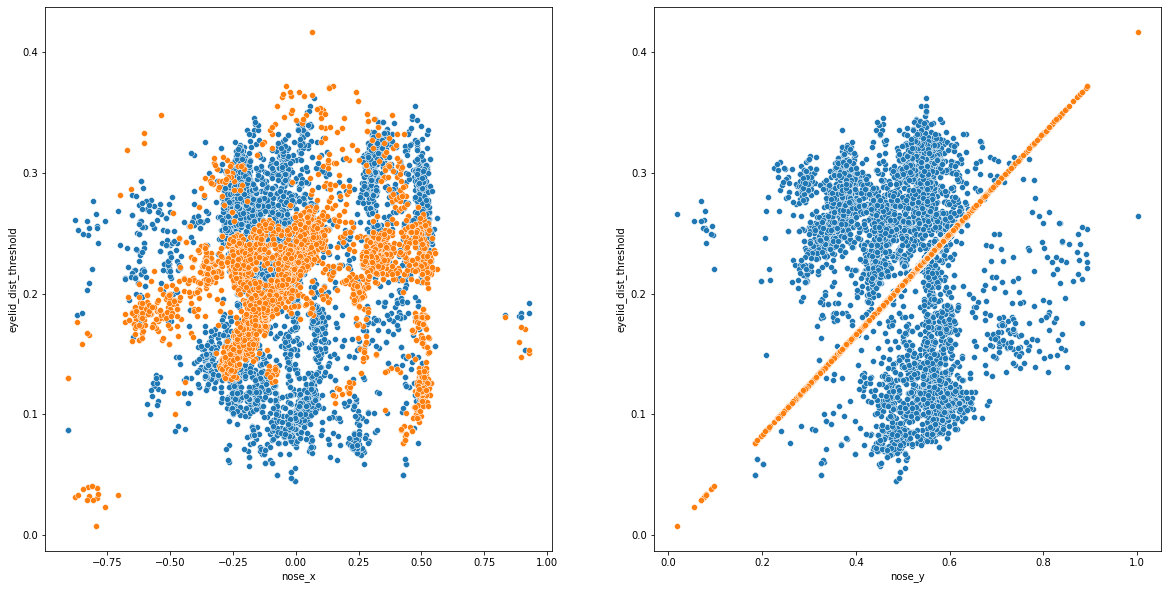

In [19]:
results = smf.ols('eyelid_dist_threshold ~ nose_y - 1', data = data).fit()
draw_stats_result(train_blinking_df, data, results, 'eyelid_dist_threshold')
results.summary2()

Mean Squared Error of Threshold Regression: 0.01235888133839547
F1 Score: 0.3744292237442922
Accuracy: 0.9648807997949244
ROC AUC Score: 0.7041739682757463


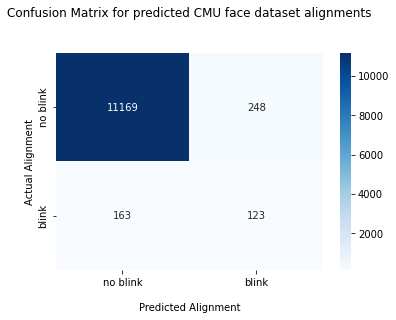

In [22]:
draw_dist_ols_confusion(results)

#### OLS Regression, eyelid_dist ~ nose_x + nose_y - 1

0.3174590301747599


<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Results: Ordinary least squares
=========================================================================
Model:              OLS                   Adj. R-squared:     0.097      
Dependent Variable: eyelid_dist_threshold AIC:                -11212.3335
Date:               2022-08-13 12:09      BIC:                -11193.0055
No. Observations:   4641                  Log-Likelihood:     5609.2     
Df Model:           2                     F-statistic:        248.9      
Df Residuals:       4638                  Prob (F-statistic): 2.12e-103  
R-squared:          0.097                 Scale:              0.0052242  
----------------------------------------------------------------------------
              Coef.     Std.Err.       t        P>|t|      [0.025     0.975]
----------------------------------------------------------------------------
Intercept     0.3258      0.0051     64.4199    0.0000     0.3159     0.3357
nose_x        0.0409      0.0040     10.3183    0.0000     0.0332     0.0487
nose_y       -0.2099      0.0099    -21.1109    0.0000    -0.2294    -0.1904
-------------------------------------------------------------------------
Omnibus:                319.071         Durbin-Watson:            0.195  
Prob(Omnibus):          0.000           Jarque-Bera (JB):         226.170
Skew:                   -0.435          Prob(JB):                 0.000  
Kurtosis:               2.357           Condition No.:            12     
=========================================================================

"""

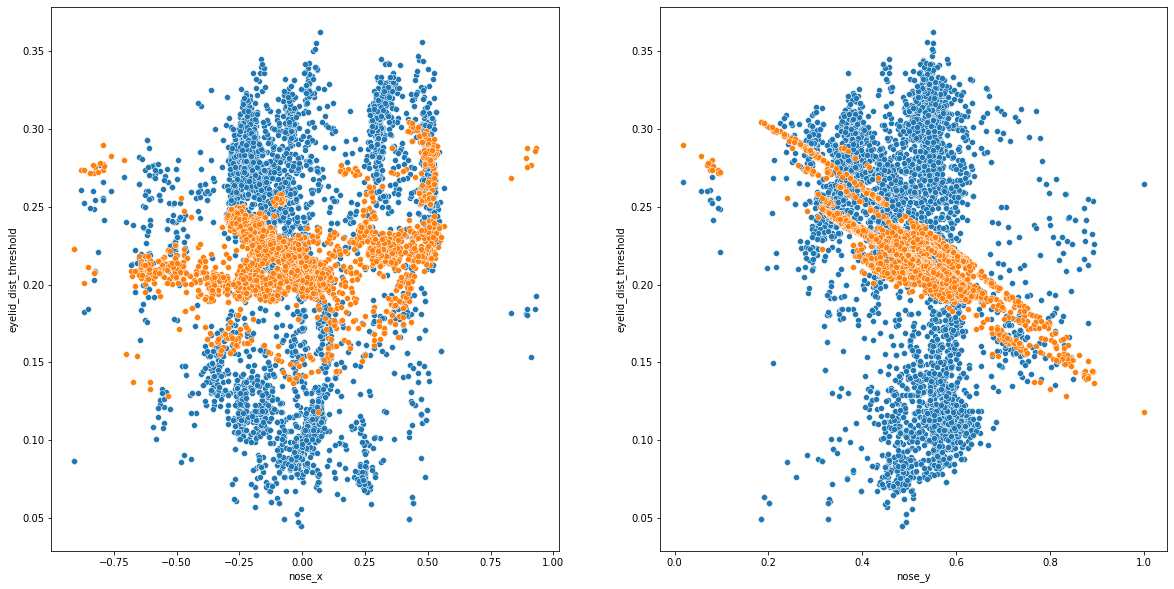

In [23]:
results = smf.ols('eyelid_dist_threshold ~ nose_x + nose_y', data = data).fit()
draw_stats_result(train_blinking_df, data, results, 'eyelid_dist_threshold')
results.summary2()

Mean Squared Error of Threshold Regression: 0.030478470932189018
F1 Score: 0.04961460086825551
Accuracy: 0.08339741946509442
ROC AUC Score: 0.5199913513831356


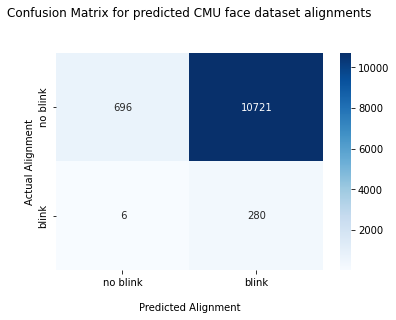

In [24]:
draw_dist_ols_confusion(results)

#### GLM Regression, eyelid_dist ~ nose_y - 1

0.4115356969494218


<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Generalized linear model
=====================================================================
Model:              GLM                   AIC:            -8250.1402 
Link Function:      identity              BIC:            -39128.1477
Dependent Variable: eyelid_dist_threshold Log-Likelihood: 4126.1     
Date:               2022-08-13 12:10      LL-Null:        5090.3     
No. Observations:   4641                  Deviance:       45.911     
Df Model:           0                     Pearson chi2:   45.9       
Df Residuals:       4640                  Scale:          0.0098947  
Method:             IRLS                                             
------------------------------------------------------------------------
            Coef.     Std.Err.       z        P>|z|     [0.025    0.975]
------------------------------------------------------------------------
nose_y      0.4163      0.0029    144.5891    0.0000    0.4106    0.4219
=====================================================================

"""

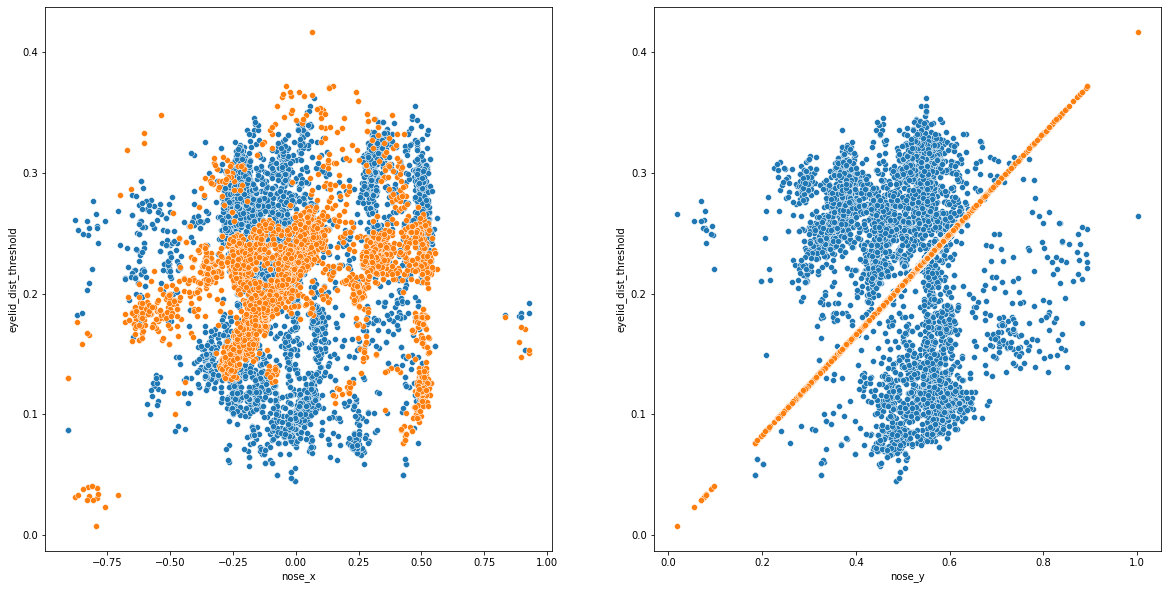

In [30]:
results = smf.glm('eyelid_dist_threshold ~ nose_y - 1', data = data).fit()
draw_stats_result(train_blinking_df, data, results, 'eyelid_dist_threshold')
results.summary2()

Mean Squared Error of Threshold Regression: 0.01235888133839547
F1 Score: 0.3744292237442922
Accuracy: 0.9648807997949244
ROC AUC Score: 0.7041739682757463


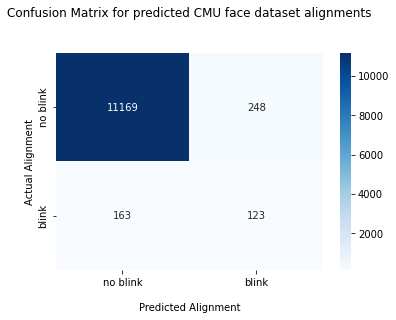

In [31]:
draw_dist_ols_confusion(results)

## Eye Aspect Ratio (EAR) Models

In [52]:
def eval_ear(df):
  vert_1 = get_distance(df, 158, 153)
  vert_2 = get_distance(df, 160, 144)
  hor = get_distance(df, 33, 133)
  eye_aspect = (vert_1 + vert_2) / (2 * hor)
  nose_coors = get_point(df, 1)
  data = pd.DataFrame(
      data = {
          'ear_threshold': eye_aspect,
          'nose_x': nose_coors[nose_coors.columns[0]],
          'nose_y': nose_coors[nose_coors.columns[1]],
      }
  )
  return data

def draw_ear_ols_confusion(results):
  eval_data = eval_ear(eval_df)
  eval_data['threshold'] = results.predict(eval_data)
  eval_data['is_blinking'] = (eval_data.ear_threshold < (eval_data.threshold)).astype(float)
  valid_idx = eval_df['is_blinking'] != 0.5
  # metrics.confusion_matrix(eval_processed_df[valid_idx].is_blinking, eval_data[valid_idx].is_blinking, labels = [0.0, 1.0])
  labels = [0.0, 1.0]
  labels_2 = ['no blink', 'blink']
  y, y_cap = eval_df[valid_idx].is_blinking, eval_data[valid_idx].is_blinking

  print(f'F1 Score: {metrics.f1_score(y, y_cap)}')
  print(f'Accuracy: {metrics.accuracy_score(y, y_cap)}')
  print(f'ROC AUC Score: {metrics.roc_auc_score(y, y_cap)}')

  cf_matrix = metrics.confusion_matrix(y, y_cap, labels = labels)
  ax = sns.heatmap(cf_matrix, annot=True, 
              fmt='2', cmap='Blues')

  ax.set_title('Confusion Matrix for predicted CMU face dataset alignments\n\n');
  ax.set_xlabel('\nPredicted Alignment')
  ax.set_ylabel('Actual Alignment');

  ## Ticket labels - List must be in alphabetical order
  ax.xaxis.set_ticklabels(labels_2)
  ax.yaxis.set_ticklabels(labels_2)

### Orientation and EAR

0.41902421186529965


<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.805     
Dependent Variable:     ear_threshold    AIC:                         -7640.4088
Date:                   2022-08-13 12:16 BIC:                         -7627.5234
No. Observations:       4641             Log-Likelihood:              3822.2    
Df Model:               2                F-statistic:                 9604.     
Df Residuals:           4639             Prob (F-statistic):          0.00      
R-squared (uncentered): 0.805            Scale:                       0.011281  
-------------------------------------------------------------------------------------
             Coef.       Std.Err.         t          P>|t|        [0.025       0.975]
-------------------------------------------------------------------------------------
nose_y       0.4241        0.0031      137.6489      0.0000       0.4181       0.4301
nose_x      -0.0401        0.0057       -6.9775      0.0000      -0.0514      -0.0288
--------------------------------------------------------------------------------
Omnibus:                  109.707            Durbin-Watson:               0.112 
Prob(Omnibus):            0.000              Jarque-Bera (JB):            73.639
Skew:                     -0.188             Prob(JB):                    0.000 
Kurtosis:                 2.511              Condition No.:               2     
================================================================================

"""

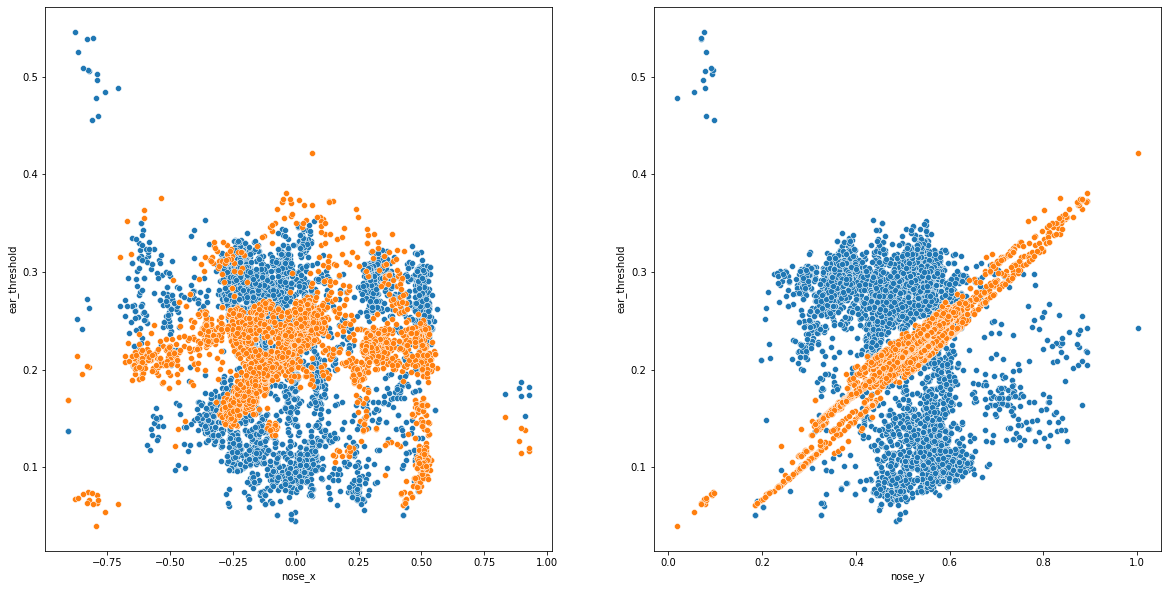

In [55]:
train_data = eval_ear(train_blinking_df)
results = smf.ols('ear_threshold ~ nose_y + nose_x - 1', data = train_data).fit()
draw_stats_result(train_blinking_df, train_data, results, 'ear_threshold')
results.summary2()

F1 Score: 0.39741518578352186
Accuracy: 0.9681278304708194
ROC AUC Score: 0.7058381532630459


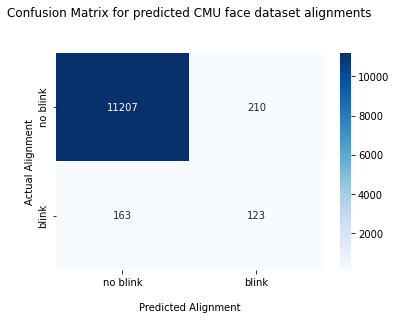

In [56]:
draw_ear_ols_confusion(results)

### Constant Threshold

F1 Score: 0.24641148325358853
Accuracy: 0.892335298641374
ROC AUC Score: 0.8084625368500293


[Text(0, 0.5, 'no blink'), Text(0, 1.5, 'blink')]

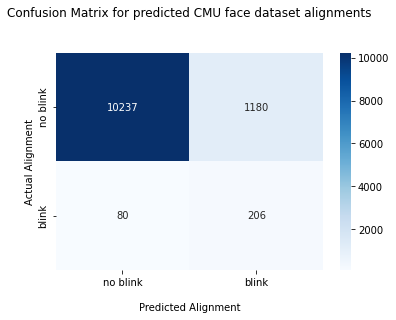

In [47]:
eval_data = eval_ear(eval_df)
### Constant Threshold
eval_data['threshold'] = 0.2
eval_data['is_blinking'] = (eval_data.ear_threshold < (eval_data.threshold)).astype(float)
valid_idx = eval_df['is_blinking'] != 0.5

y, y_cap = eval_df[valid_idx].is_blinking, eval_data[valid_idx].is_blinking

print(f'F1 Score: {metrics.f1_score(y, y_cap)}')
print(f'Accuracy: {metrics.accuracy_score(y, y_cap)}')
print(f'ROC AUC Score: {metrics.roc_auc_score(y, y_cap)}')

# metrics.confusion_matrix(eval_processed_df[valid_idx].is_blinking, eval_data[valid_idx].is_blinking, labels = [0.0, 1.0])
labels = [0.0, 1.0]
labels_2 = ['no blink', 'blink']
cf_matrix = metrics.confusion_matrix(y, y_cap, labels = labels)
ax = sns.heatmap(cf_matrix, annot=True, 
            fmt='2', cmap='Blues')

ax.set_title('Confusion Matrix for predicted CMU face dataset alignments\n\n');
ax.set_xlabel('\nPredicted Alignment')
ax.set_ylabel('Actual Alignment');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(labels_2)
ax.yaxis.set_ticklabels(labels_2)

## Candid EAR

F1 Score: 0.24641148325358853
Accuracy: 0.892335298641374
ROC AUC Score: 0.8084625368500293


[Text(0, 0.5, 'no blink'), Text(0, 1.5, 'blink')]

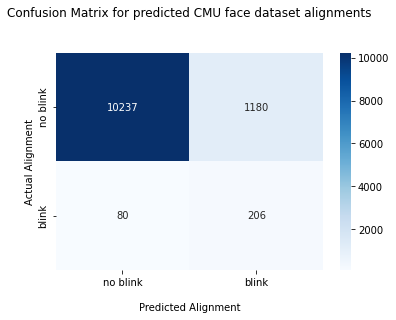

In [48]:
train_df = pd.read_csv('train_rtbene_candid_coors.csv', index_col = 0)
train_blinking_df = train_df[train_df.is_blinking == 1.0]
eval_df = pd.read_csv('test_rtbene_candid_coors.csv', index_col = 0)

eval_data = eval_ear(eval_df)
eval_data['threshold'] = 0.2
eval_data['is_blinking'] = (eval_data.ear_threshold < (eval_data.threshold)).astype(float)
valid_idx = eval_df['is_blinking'] != 0.5

y, y_cap = eval_df[valid_idx].is_blinking, eval_data[valid_idx].is_blinking

print(f'F1 Score: {metrics.f1_score(y, y_cap)}')
print(f'Accuracy: {metrics.accuracy_score(y, y_cap)}')
print(f'ROC AUC Score: {metrics.roc_auc_score(y, y_cap)}')

# metrics.confusion_matrix(eval_processed_df[valid_idx].is_blinking, eval_data[valid_idx].is_blinking, labels = [0.0, 1.0])
labels = [0.0, 1.0]
labels_2 = ['no blink', 'blink']
cf_matrix = metrics.confusion_matrix(y, y_cap, labels = labels)
ax = sns.heatmap(cf_matrix, annot=True, 
            fmt='2', cmap='Blues')

ax.set_title('Confusion Matrix for predicted CMU face dataset alignments\n\n');
ax.set_xlabel('\nPredicted Alignment')
ax.set_ylabel('Actual Alignment');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(labels_2)
ax.yaxis.set_ticklabels(labels_2)
